In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import hashlib
import glob

In [2]:
import src.img as iImg

In [3]:
df = pd.read_parquet("data/dataset.parquet.gzip")
df = df[df.Place == "Paris"].reset_index(drop=True)
print(len(df.Source.unique()))
df

550


,Identifiant du projet lauréat,Lien URL vers le projet soumis au vote,Lien URL vers le projet lauréat,Edition,Thématique,Budget global du projet lauréat,Echelle du Budget participatif,Arrondissement du projet lauréat,Projet en Quartier populaire,Avancement du projet,...,Place,Type,Justification,Purpose,Issue,Scale,Score,Justification_Short,Source_Title,Reviewed
0,3365,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Cadre de vie,31000,Budget participatif d’arrondissement,75004,Non,FIN,...,Paris,Activities,The enhancement of the bridge can positively a...,Attractiveness,Living and working environment,Neighbourhood,3,Bridge enhancement improves community appeal.,Beautification project for Louis Philippe Bridge.,False
1,3365,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Cadre de vie,31000,Budget participatif d’arrondissement,75004,Non,FIN,...,Paris,Activities,The project can improve community resilience b...,Resilience,Mobility,Neighbourhood,3,Enhancing community resilience through mobility.,Beautification project for Louis Philippe Bridge.,False
2,3365,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Cadre de vie,31000,Budget participatif d’arrondissement,75004,Non,FIN,...,Paris,Activities,The enhancement of the bridge can positively a...,Attractiveness,Living and working environment,Neighbourhood,3,Bridge enhancement improves community appeal.,Beautification project for Louis Philippe Bridge.,False
3,3365,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Cadre de vie,31000,Budget participatif d’arrondissement,75004,Non,FIN,...,Paris,Activities,The project focuses on creating a space for pe...,Social cohesion,"Living together, interdependence and mutuality",Neighbourhood,5,Promoting community through social interaction.,Beautification project for Louis Philippe Bridge.,False
4,3365,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Cadre de vie,31000,Budget participatif d’arrondissement,75004,Non,FIN,...,Paris,Activities,The project's aim to enhance the Louis Philipp...,Attractiveness,Mobility,Neighbourhood,4,Enhancing Louis Philippe bridge accessibility.,Beautification project for Louis Philippe Bridge.,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6701,3788,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Solidarités,3500000,Budget participatif parisien,75004,Non,LIVRAISON,...,Paris,Activities,The text emphasizes the role of community coll...,Social cohesion,"Living together, interdependence and mutuality",Neighbourhood,5,Community collaboration fosters social ties.,Waste reduction and resource sharing.,False
6702,3788,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Solidarités,3500000,Budget participatif parisien,75004,Non,LIVRAISON,...,Paris,Activities,The initiatives detailed promote environmental...,Preservation and improvement of environment,Biodiversity and ecosystem services,Neighbourhood,5,Promotes sustainability and biodiversity initi...,Waste reduction and resource sharing.,False
6703,3788,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Solidarités,3500000,Budget participatif parisien,75004,Non,LIVRAISON,...,Paris,Activities,The community initiatives enhance resilience b...,Resilience,Living and working environment,Neighbourhood,4,Community initiatives boost resilience and jobs.,Waste reduction and resource sharing.,False
6704,3788,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2017,Solidarités,3500000,Budget participatif parisien,75004,Non,LIVRAISON,...,Paris,Activities,"By p

/home/kelu/projets/pariso37k/src/img.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/pariso37k/src/img.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')


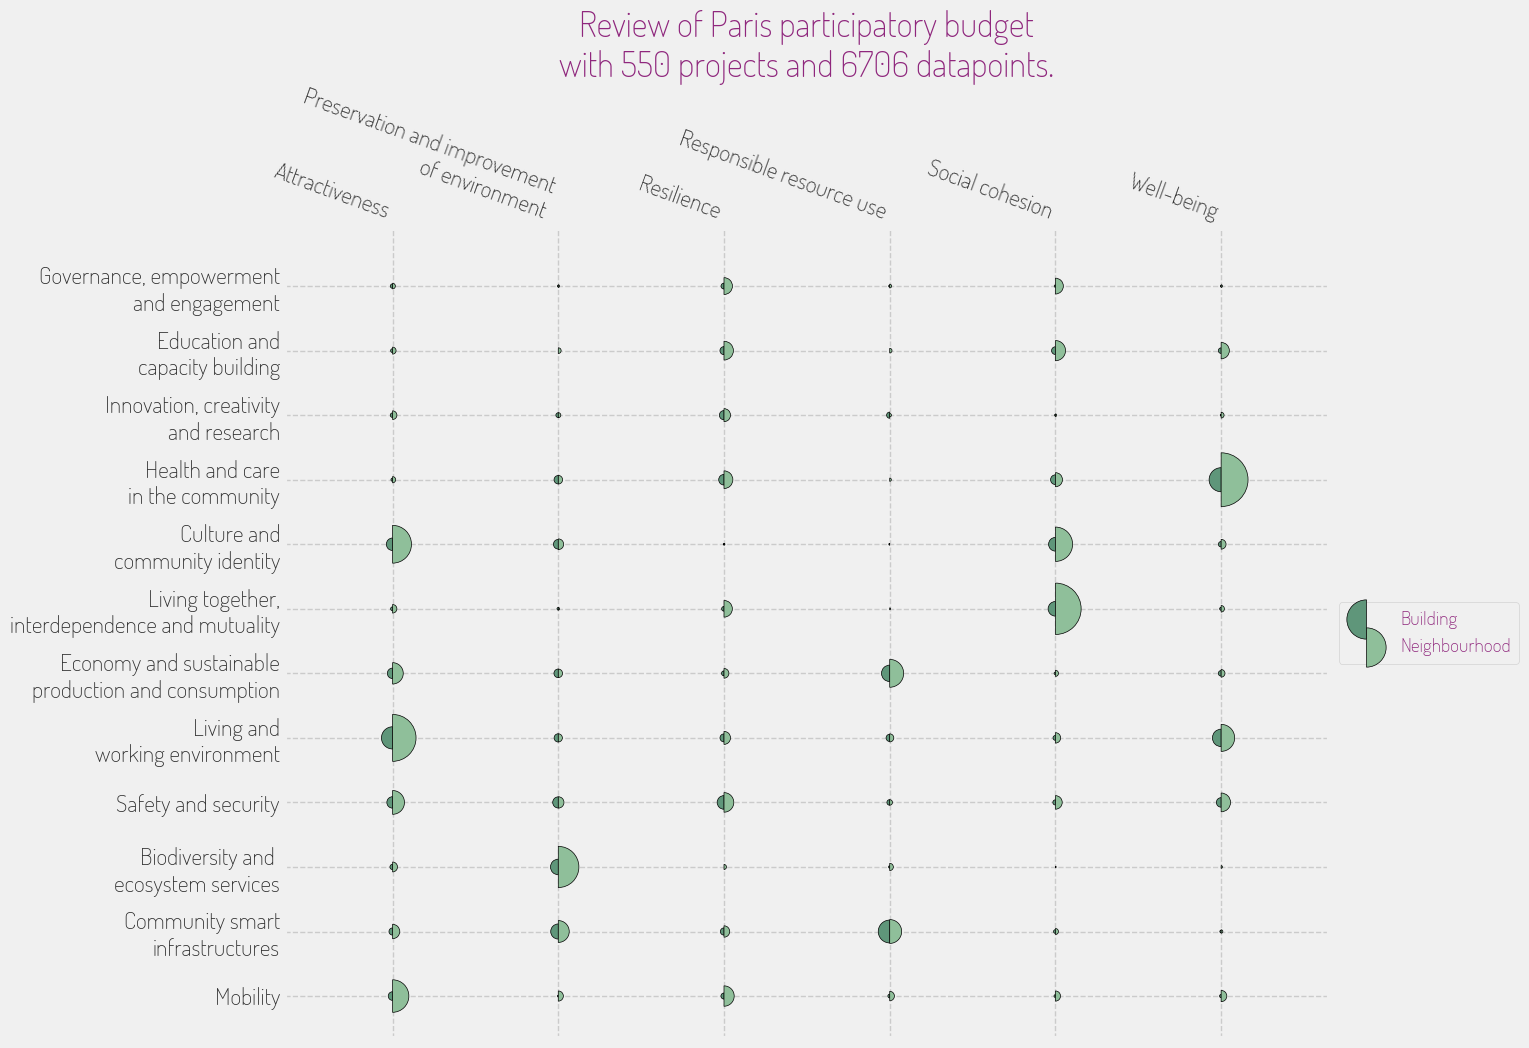

In [4]:
dfRef = pd.DataFrame(columns=df.columns)
dfUC = df
plt, ax = iImg.createImg(dfUC,dfRef,title="Review of Paris participatory budget\nwith "+str(len(df.Source.unique())) +" projects and "+str(len(df))+" datapoints.")
plt.savefig("outputs/Paris.png", bbox_inches='tight')
plt.savefig("outputs/Paris.svg", bbox_inches='tight')

In [5]:
for ISSUE in df.Issue.unique():
    pc = len(df[df.Issue == ISSUE].Source.unique()) / len(df.Source.unique())
    print(ISSUE, int(pc*1000)/10)

Living and working environment 94.5
Mobility 59.2
Living together, interdependence and mutuality 90.0
Culture and community identity 86.1
Safety and security 72.9
Community smart infrastructures 76.3
Health and care in the community 96.7
Education and capacity building 41.4
Economy and sustainable production and consumption 68.1
Biodiversity and ecosystem services 66.3
Governance, empowerment and engagement 26.1
Innovation, creativity and research 20.7


In [6]:
for PURPOSE in df.Purpose.unique():
    pc = len(df[df.Purpose == PURPOSE].Source.unique()) / len(df.Source.unique())
    print(PURPOSE, int(pc*1000)/10)

Attractiveness 99.8
Resilience 91.4
Social cohesion 99.2
Preservation and improvement of environment 92.7
Well-being 99.8
Responsible resource use 81.4
